# Netflix Data Analysis

## Introduction

This project analyzes the Netflix dataset to explore trends in movies and TV shows.

We examine:
- Content growth over time
- Differences between movies and TV shows
- Top countries and genres

Import Libraries

In [16]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
import seaborn as sns

Load dataset and cleaning

In [17]:
sns.set_style("whitegrid")
df=pd.read_csv("netflix introduction/netflix_titles.csv")
df['country']=df['country'].fillna("Unknown")
df['director']=df['director'].fillna("Unknown")
df['cast']=df['cast'].fillna("Unknown")
print(df.isnull().sum())

show_id          0
type             0
title            0
director         0
cast             0
country          0
date_added      10
release_year     0
rating           4
duration         3
listed_in        0
description      0
dtype: int64


Released Movies Per year

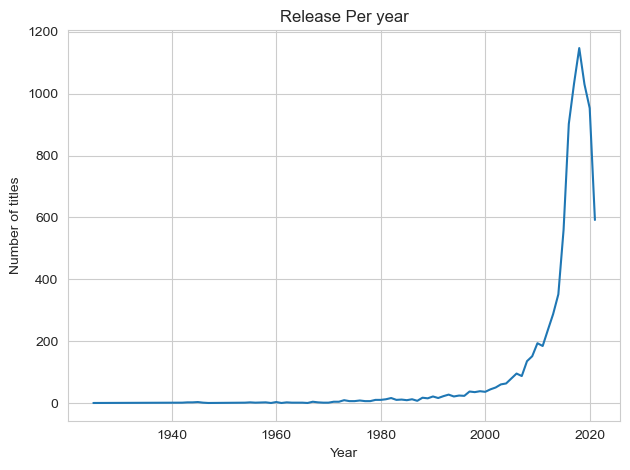

In [18]:
year_counts=df['release_year'].value_counts().sort_index().reset_index()
year_counts.columns=['year','count']
sns.lineplot(x='year',y='count', data=year_counts)
plt.title("Release Per year")
plt.xlabel("Year")
plt.ylabel("Number of titles")
plt.tight_layout()
plt.savefig("ReleasePerYear.png")
plt.show()

Movies vs TV Shows Releases Per Year

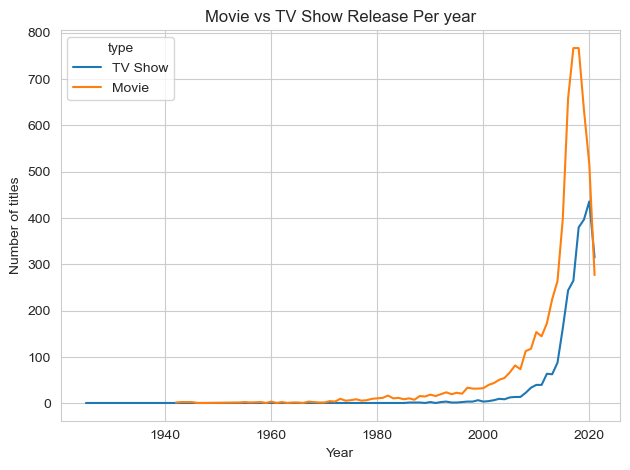

In [19]:
type_peryear=df.groupby(['release_year','type'])['title'].count().reset_index()
type_peryear.columns=['release_year','type','count']
sns.lineplot(x='release_year',y='count',hue='type', data=type_peryear)
plt.title("Movie vs TV Show Release Per year")
plt.xlabel("Year")
plt.ylabel("Number of titles")
plt.tight_layout()
plt.savefig("MoviesvsTVShows.png")
plt.show()

Top 10 Countries by number of releases

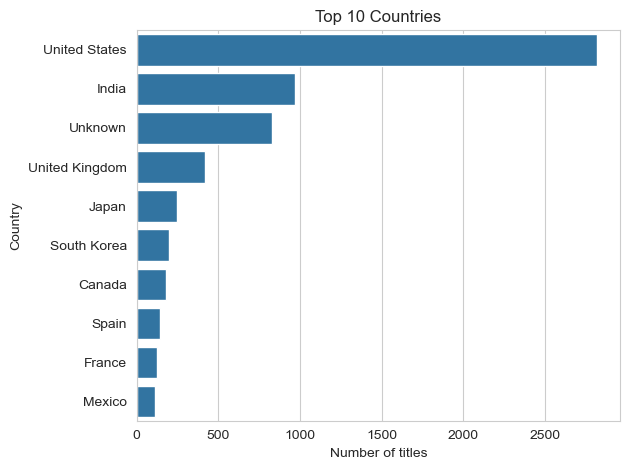

In [20]:
countries=df.groupby('country')['title'].count().reset_index()
countries.columns=['country','count']
top_countries=countries.sort_values(by='count',ascending=False).head(10)
sns.barplot(y='country',x='count', data=top_countries)
plt.title("Top 10 Countries")
plt.ylabel("Country")
plt.xlabel("Number of titles")
plt.tight_layout()
plt.savefig("Top10Countries.png")
plt.show()

Top 10 Genres by number of titles

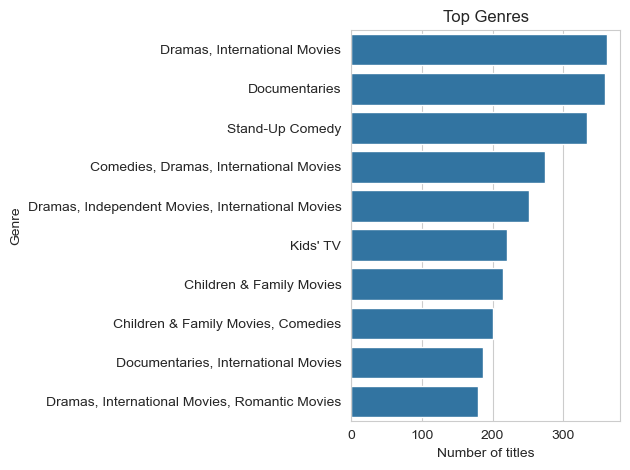

In [21]:
genres=df.groupby('listed_in')['title'].count().reset_index()
genres.columns=['genre','count']
top_genres=genres.sort_values(by='count',ascending=False).head(10)
sns.barplot(x='count',y='genre', data=top_genres)
plt.title("Top Genres")
plt.xlabel("Number of titles")
plt.ylabel("Genre")
plt.tight_layout()
plt.savefig("top10genres.png")
plt.show()

Correlation Heatmap of title length and release year

              release_year  title_length
release_year      1.000000      0.031563
title_length      0.031563      1.000000


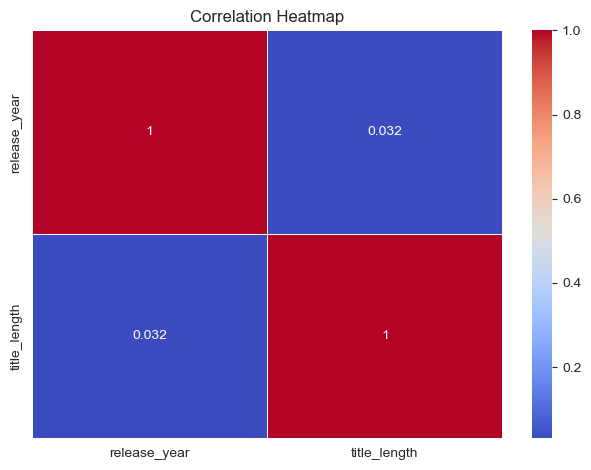

In [23]:
df['title_length'] = df['title'].apply(len)
numeric_df = df.select_dtypes(include=['number'])
corr_matrix = numeric_df.corr()
print(corr_matrix)
sns.heatmap(corr_matrix, cmap='coolwarm',annot=True,linewidths=0.5)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig("heatmap.png")
plt.show()

Movies vs TV Shows Distribution

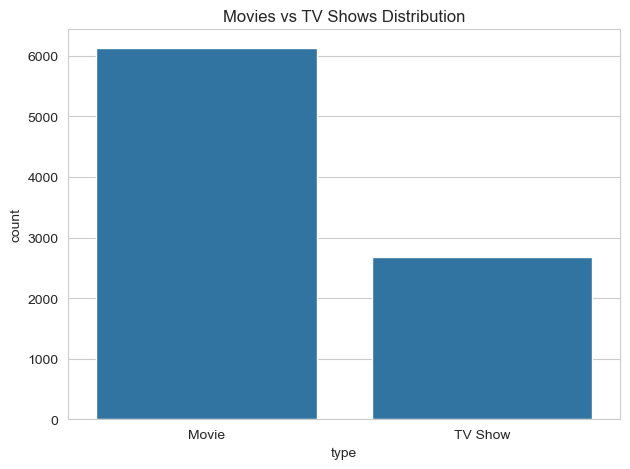

In [24]:
sns.countplot(x='type', data=df)
plt.title("Movies vs TV Shows Distribution")
plt.tight_layout()
plt.savefig("movies_vs_tvshows_distribution.png")
plt.show()

## Insights

- Netflix content increased significantly after 2015
- Movies are more common than TV shows
- The United States produces the most content
- Drama and International Movies are among the most popular genres